# Patent Topic Modeling with TF‑IDF + NMF


In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF

import re
from pathlib import Path


## Step 1 — Load and Combine Text

In [13]:
df = pd.read_csv("../data/patents/v1_core_expansion/core/raw/sw_keyword_35000.csv")

print(f"Dataset loaded: {df.shape[0]} patents")

# Combine title + abstract for maximum signal
df["text"] = (
    df["Title"].fillna("") + ". " + df["Abstract"].fillna("")
)

# Convert to list for processing
docs = df["text"].astype(str).tolist()


Dataset loaded: 38284 patents


## Step 2 — Remove Patent + GPU Boilerplate

You can aggressively strip boilerplate to improve topic purity. Tune this list over time.

In [14]:
# Patent boilerplate + GPU/HW generic boilerplate you often see in abstracts.
# Keep this list short and high-signal; too much removal can erase real meaning.
custom_stopwords = [
    # patent boilerplate
    "method", "methods", "apparatus", "system", "systems", "device", "devices",
    "embodiment", "embodiments", "disclosed", "discloses", "present", "invention",
    "described", "includes", "including", "provide", "provides", "provided",
    "example", "examples", "exemplary",

    # generic compute boilerplate
    "processor", "processors", "cpu", "cpus", "computing", "computer", "computers",
    "memory", "memories", "data", "information", "network", "networks",

    # very generic GPU words (optional — comment out if you want these to anchor topics)
    "gpu", "gpus", "graphics", "rendering"
]

stop_words = set(ENGLISH_STOP_WORDS).union(set(custom_stopwords))

# Optional phrase-level removals (regex). Add domain boilerplate here.
regex_phrases_to_remove = [
    r"one or more",
    r"at least one",
    r"in some embodiments?",
    r"according to (some|one) embodiments?",
    r"non-transitory computer-readable medium",
    r"computer readable medium",
]

def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9_\s\-]", " ", s)         # keep alnum/_/- as token-friendly
    for pat in regex_phrases_to_remove:
        s = re.sub(pat, " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_clean"] = df["text"].map(clean_text)

# Quick sanity check
df[["text","text_clean"]].head(3)


,text,text_clean
0,ANCHORING VIRTUAL IMAGES TO REAL WORLD SURFACE...,anchoring virtual images to real world surface...
1,SYSTEMS AND METHODS FOR SAFE AND RELIABLE AUTO...,systems and methods for safe and reliable auto...
2,EFFICIENT DUPLICATE DETECTION FOR MACHINE LEAR...,efficient duplicate detection for machine lear...


## Step 3 — Vectorize with TF‑IDF

In [15]:
# Vectorizer settings:
# - ngram_range=(1,2): bigrams help for patent phrases ("memory controller", "cache coherence", ...)
# - min_df: ignore very rare terms
# - max_df: ignore extremely common terms
vectorizer = TfidfVectorizer(
    stop_words=list(stop_words),
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.6,
    lowercase=False,         # already cleaned
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9_]{1,}\b"  # >=2 chars, starts with letter
)

X = vectorizer.fit_transform(df["text_clean"])
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"TF‑IDF matrix shape: {X.shape}  (docs × terms)")
print(f"Vocabulary size: {len(feature_names):,}")


TF‑IDF matrix shape: (38284, 32473)  (docs × terms)
Vocabulary size: 32,473


## Step 4 — Fit NMF Topic Model

In [8]:
# NMF hyperparameters
n_topics = 20

nmf = NMF(
    n_components=n_topics,
    init="nndsvda",
    random_state=42,
    max_iter=500,
    alpha_W=0.0,        # regularization on W (doc-topic)
    alpha_H=0.0,        # regularization on H (topic-term)
    l1_ratio=0.0
)

W = nmf.fit_transform(X)  # doc-topic matrix
H = nmf.components_       # topic-term matrix

print(f"W shape: {W.shape} (docs × topics)")
print(f"H shape: {H.shape} (topics × terms)")
print(f"Reconstruction error: {nmf.reconstruction_err_:.4f}")


W shape: (38284, 20) (docs × topics)
H shape: (20, 32473) (topics × terms)
Reconstruction error: 188.5117


## Step 5 — Inspect Topics

In [9]:
def print_top_words(H, feature_names, n_top_words=15):
    for topic_idx, topic in enumerate(H):
        top = np.argsort(topic)[::-1][:n_top_words]
        words = feature_names[top]
        weights = topic[top]
        print(f"Topic {topic_idx:02d}: " + ", ".join([f"{w}" for w in words]))
        # Uncomment if you want weights
        # print("  " + " | ".join([f"{w}:{weights[i]:.3f}" for i,w in enumerate(words)]))

print_top_words(H, feature_names, n_top_words=20)


Topic 00: processing, unit, processing unit, units, processing units, configured, pipeline, central, central processing, parallel, operations, unit processing, multiple, second processing, commands, mode, unit configured, process, power, image processing
Topic 01: cache, line, cache line, level, level cache, lines, cache lines, request, cache controller, cache cache, prefetch, controller, access, tag, second cache, core, shared, caches, requests, coherency
Topic 02: image, image processing, second image, images, input image, image based, feature, image image, processing, camera, image frame, image second, resolution, based, target, image using, processing image, color, input, obtain
Topic 03: model, learning, machine learning, machine, learning model, training, models, ml, trained, using, learning models, ml model, based, set, ai, training machine, using machine, model based, parameters, inference
Topic 04: storage, controller, host, command, write, volatile, request, storage controlle

## Step 6 — Assign Dominant Topic per Document (and save)

This mirrors the usual downstream workflow: add `topic_id` and the full topic weight vector to your dataframe for analysis/plotting.

In [ ]:
df_topics = df.copy()

# Dominant topic (argmax)
df_topics["nmf_topic"] = W.argmax(axis=1).astype(int)

# Optionally store the whole weight vector as separate columns
topic_cols = [f"topic_{i}" for i in range(n_topics)]
df_topics[topic_cols] = W

df_topics[["nmf_topic"] + topic_cols[:5]].head()


In [ ]:
# Save enriched dataset (optional)
OUT_PATH = Path("../data/patents/v1_core_expansion/core/derived/nmf_tfidf_topics.csv")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_topics.to_csv(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH.resolve()}")


## Optional — Sweep K (number of topics)

For NMF, common heuristics are:
- **Reconstruction error** (lower is better, but monotonically decreases with K)
- **Topic diversity** (how many unique top-words across topics; higher is better)

This cell computes both across a small grid.

In [10]:
from sklearn.preprocessing import normalize

def topic_diversity(H, feature_names, topn=20):
    # fraction of unique words in topn lists across all topics
    top_words = []
    for k in range(H.shape[0]):
        top = np.argsort(H[k])[::-1][:topn]
        top_words.extend(feature_names[top].tolist())
    return len(set(top_words)) / (H.shape[0] * topn)

k_values = [10, 15, 20, 25, 30, 40]
rows = []

for k in k_values:
    model = NMF(
        n_components=k,
        init="nndsvda",
        random_state=42,
        max_iter=500,
        alpha_W=0.0,
        alpha_H=0.0,
        l1_ratio=0.0
    )
    Wk = model.fit_transform(X)
    Hk = model.components_
    rows.append({
        "k": k,
        "reconstruction_error": model.reconstruction_err_,
        "topic_diversity_top20": topic_diversity(Hk, feature_names, topn=20),
        "avg_topic_sparsity": float((Hk == 0).mean())
    })

results = pd.DataFrame(rows)
results


,k,reconstruction_error,topic_diversity_top20,avg_topic_sparsity
0,10,190.708574,0.815000,0.575925
1,15,189.533891,0.820000,0.653959
2,20,188.511668,0.777500,0.697022
3,25,187.570279,0.760000,0.721271
4,30,186.696435,0.751667,0.743633
5,40,185.040167,0.735000,0.777128


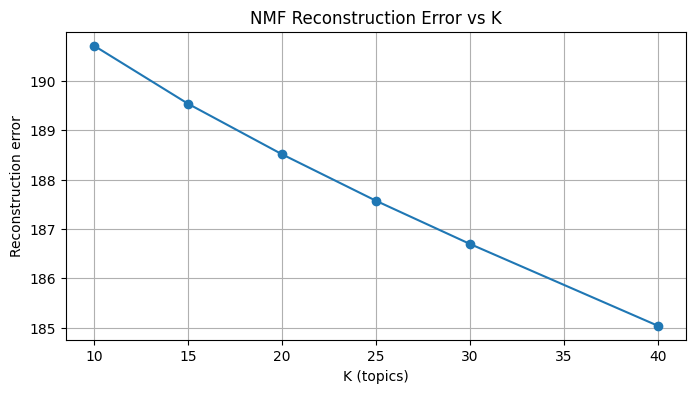

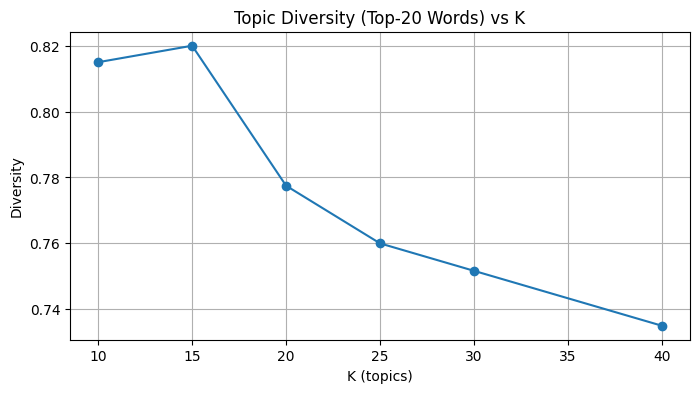

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(results["k"], results["reconstruction_error"], marker="o")
plt.title("NMF Reconstruction Error vs K")
plt.xlabel("K (topics)")
plt.ylabel("Reconstruction error")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(results["k"], results["topic_diversity_top20"], marker="o")
plt.title("Topic Diversity (Top-20 Words) vs K")
plt.xlabel("K (topics)")
plt.ylabel("Diversity")
plt.grid(True)
plt.show()


## Optional — Quick Stability Check Across Seeds (Top-word Jaccard)

This is a lightweight analogue to your LDA stability checks. It compares topic top-word sets across different `random_state` values and reports the average best-match Jaccard similarity.

Note: NMF can be sensitive to initialization; using `init='nndsvda'` typically helps.

In [12]:
import itertools

def top_word_sets(H, feature_names, topn=25):
    sets = []
    for k in range(H.shape[0]):
        top = np.argsort(H[k])[::-1][:topn]
        sets.append(set(feature_names[top]))
    return sets

def jaccard(a, b):
    return len(a & b) / max(1, len(a | b))

def greedy_best_match_jaccard(sets1, sets2):
    # Greedy alignment for speed; if you want optimal, swap in Hungarian matching.
    used = set()
    scores = []
    for s1 in sets1:
        best = 0.0
        best_j = None
        for j, s2 in enumerate(sets2):
            if j in used:
                continue
            sc = jaccard(s1, s2)
            if sc > best:
                best = sc
                best_j = j
        if best_j is not None:
            used.add(best_j)
        scores.append(best)
    return float(np.mean(scores))

seeds = [1, 7, 21, 42, 99]
k = n_topics
topn = 25

topic_sets_by_seed = {}
for seed in seeds:
    model = NMF(
        n_components=k,
        init="nndsvda",
        random_state=seed,
        max_iter=500
    )
    W_ = model.fit_transform(X)
    H_ = model.components_
    topic_sets_by_seed[seed] = top_word_sets(H_, feature_names, topn=topn)

pairs = list(itertools.combinations(seeds, 2))
pair_scores = []
for s1, s2 in pairs:
    score = greedy_best_match_jaccard(topic_sets_by_seed[s1], topic_sets_by_seed[s2])
    pair_scores.append({"seed_a": s1, "seed_b": s2, "avg_best_jaccard": score})

pd.DataFrame(pair_scores).sort_values("avg_best_jaccard", ascending=False)


,seed_a,seed_b,avg_best_jaccard
2,1,42,0.824288
5,7,42,0.760518
9,42,99,0.754486
8,21,99,0.691193
4,7,21,0.688277
3,1,99,0.685024
0,1,7,0.678824
6,7,99,0.673978
7,21,42,0.619290
1,1,21,0.541117
